In [15]:
import pandas as pd

In [24]:
#import and load the data
import pandas as pd

# load excel file
file_path = "C:/Users/ahafeez7/Downloads/tables.xlsx"

p_DNR = pd.read_excel(file_path, sheet_name="p(DNR)")
p_outcome_tx_sev = pd.read_excel(file_path, sheet_name="p(Outcome|Tx,Severity)")
p_severity = pd.read_excel(file_path, sheet_name="p(severity)")
p_Tx_DNR_sev = pd.read_excel(file_path, sheet_name="p(Tx|DNR,Severity)")

In [25]:
#remove NOT SEVERE
p_outcome_tx_sev = p_outcome_tx_sev[~p_outcome_tx_sev["Severity"].str.contains("Not Severe")]
p_severity = p_severity[~p_severity["Severity"].str.contains("Not Severe")]
p_Tx_DNR_sev = p_Tx_DNR_sev[~p_Tx_DNR_sev["Severity"].str.contains("Not Severe")]

In [26]:
# compute P(Severity, DNR)
# cross join
sevDNR = p_severity.merge(p_DNR, how="cross")

# multiply probabilities
sevDNR["p"] = sevDNR["p_x"] * sevDNR["p_y"]

sevDNR = sevDNR[["Severity", "DNR", "p"]]

In [27]:
# compute P(Tx, Severity, DNR)

severity = pd.merge(
    sevDNR,
    p_Tx_DNR_sev,
    on=["Severity", "DNR"]
)

severity["p"] = severity["p_x"] * severity["p_y"]

severity = severity[["Tx", "Severity", "DNR", "p"]]

In [29]:
# marginalize DNR → P(Tx, Severity)
TX_sev = (
    severity
    .groupby(["Tx", "Severity"], as_index=False)["p"]
    .sum()
    .rename(columns={"p": "psum"})
)

In [31]:
# join outcome 
Tx_sev_outcome = pd.merge(
    TX_sev,
    p_outcome_tx_sev,
    on=["Tx", "Severity"]
)

Tx_sev_outcome["p"] = Tx_sev_outcome["psum"] * Tx_sev_outcome["p"]

In [32]:
# final outcome distribution
outcome = (
    Tx_sev_outcome
    .groupby(["Severity", "Outcome"], as_index=False)["p"]
    .sum()
)

In [33]:
# normalize
total = outcome["p"].sum()

outcome["p_normalized"] = outcome["p"] / total

outcome

,Severity,Outcome,p,p_normalized
0,Severe,Negative,0.0244,0.476562
1,Severe,Positive,0.0268,0.523438


In [34]:
# probability of negative outcome given
result = outcome[
    (outcome["Severity"] == "Severe") &
    (outcome["Outcome"] == "Negative")
]

print(result)

  Severity   Outcome       p  p_normalized
0   Severe  Negative  0.0244      0.476562


In [38]:
# probabilities sum to 1
outcome["p_normalized"] = outcome["p"] / total
outcome

,Severity,Outcome,p,p_normalized
0,Severe,Negative,0.0244,0.476562
1,Severe,Positive,0.0268,0.523438


In [35]:
print("""
Interpretation:
- We computed P(Negative Outcome | Severe, DNR = No)
- Irrelevant category 'Not Severe' was removed
- Probabilities were combined using joint and conditional rules
- Final result is normalized to ensure probabilities sum to 1
""")


Interpretation:
- We computed P(Negative Outcome | Severe, DNR = No)
- Irrelevant category 'Not Severe' was removed
- Probabilities were combined using joint and conditional rules
- Final result is normalized to ensure probabilities sum to 1



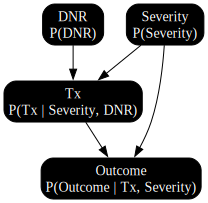

In [46]:
from graphviz import Digraph

dot = Digraph()

# global node style
dot.attr('node',
         shape='rectangle',
         style='filled,rounded',
         fillcolor='tealblue',
         fontcolor='white')

# nodes
dot.node('Severity', 'Severity\nP(Severity)')
dot.node('DNR', 'DNR\nP(DNR)')
dot.node('Tx', 'Tx\nP(Tx | Severity, DNR)')
dot.node('Outcome', 'Outcome\nP(Outcome | Tx, Severity)')

# edges
dot.edge('Severity', 'Tx')
dot.edge('DNR', 'Tx')
dot.edge('Tx', 'Outcome')
dot.edge('Severity', 'Outcome')

dot